In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy import stats

from pathlib import Path

sns.set_theme(style='whitegrid')

In [21]:
columns = (
    ["unit_number", "cycle_number"]
    + [f"op_settings_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

file_path = Path("../data/train_FD001.txt")

df = pd.read_csv(file_path, sep=r"\s+", header=None, names=columns)

print(df.shape)
print(df.dtypes)
print(df.isna().sum().sum())
print(df['unit_number'].nunique())

(20631, 26)
unit_number        int64
cycle_number       int64
op_settings_1    float64
op_settings_2    float64
op_settings_3    float64
sensor_1         float64
sensor_2         float64
sensor_3         float64
sensor_4         float64
sensor_5         float64
sensor_6         float64
sensor_7         float64
sensor_8         float64
sensor_9         float64
sensor_10        float64
sensor_11        float64
sensor_12        float64
sensor_13        float64
sensor_14        float64
sensor_15        float64
sensor_16        float64
sensor_17          int64
sensor_18          int64
sensor_19        float64
sensor_20        float64
sensor_21        float64
dtype: object
0
100


In [22]:
max_cycles = df.groupby("unit_number")["time_in_cycle"].transform("max")
df["RUL"] = max_cycles - df['time_in_cycle']

KeyError: 'Column not found: time_in_cycle'

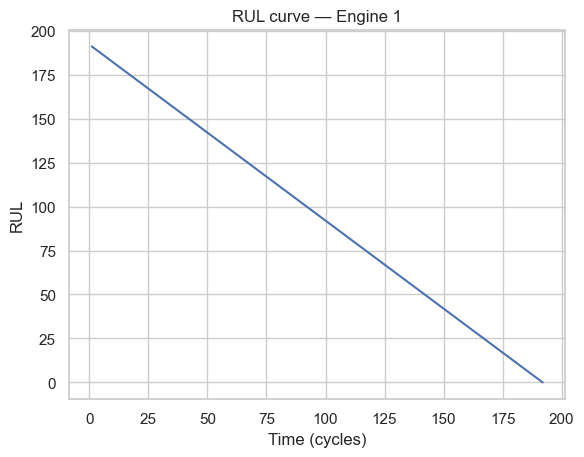

In [ ]:
engine_1 = df[df["unit_number"] == 1]
plt.plot(engine_1["time_in_cycle"], engine_1["RUL"])
plt.xlabel("Time (cycles)")
plt.ylabel("RUL")
plt.title("RUL curve — Engine 1")
plt.show()

In [ ]:
missing_values = df.isnull().sum()

print(missing_values)
print("\nTotal missing values:", missing_values.sum())

unit_number      0
time_in_cycle    0
op_settings_1    0
op_settings_2    0
op_settings_3    0
sensor_1         0
sensor_2         0
sensor_3         0
sensor_4         0
sensor_5         0
sensor_6         0
sensor_7         0
sensor_8         0
sensor_9         0
sensor_10        0
sensor_11        0
sensor_12        0
sensor_13        0
sensor_14        0
sensor_15        0
sensor_16        0
sensor_17        0
sensor_18        0
sensor_19        0
sensor_20        0
sensor_21        0
RUL              0
dtype: int64

Total missing values: 0


In [ ]:
num_engines = df['unit_number'].nunique()

print("Number of engines:", num_engines)

Number of engines: 100


In [ ]:
engine_lifetime = df.groupby("unit_number")["time_in_cycle"].max()

engine_lifetime.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycle, dtype: float64

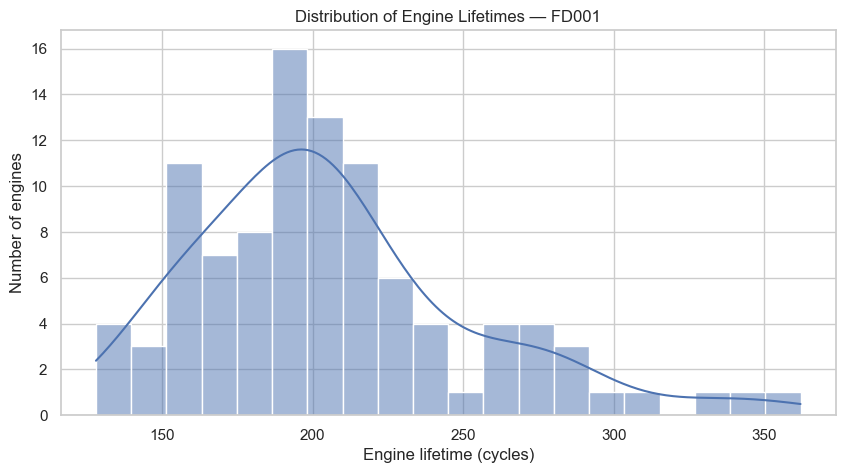

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(engine_lifetime, bins=20, kde=True)

plt.xlabel("Engine lifetime (cycles)")
plt.ylabel("Number of engines")
plt.title("Distribution of Engine Lifetimes — FD001")

plt.show()

In [ ]:
def plot_sensor_trajectories(df, sensor_list, n_engines=5):
    sample_units = np.random.choice(df["unit_number"].unique(), n_engines)

    fig, axes = plt.subplots(7, 3, figsize=(15, 20))
    fig.suptitle("Sensor degradation trajectories across sample engines",fontsize=18,fontweight="bold")
    axes = axes.flatten()

    for i, sensor in enumerate(sensor_list):
        for unit in sample_units:
            engine_data = df[df["unit_number"] == unit].sort_values(["time_in_cycle"])
            axes[i].plot(engine_data["time_in_cycle"], engine_data[sensor], label=f"Unit {unit}")
        axes[i].set_xlabel("Time in Cycle")
        axes[i].set_ylabel(sensor)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="lower center", ncol=n_engines, bbox_to_anchor=(0.5, -0.01)
    )

    plt.tight_layout()
    plt.show()

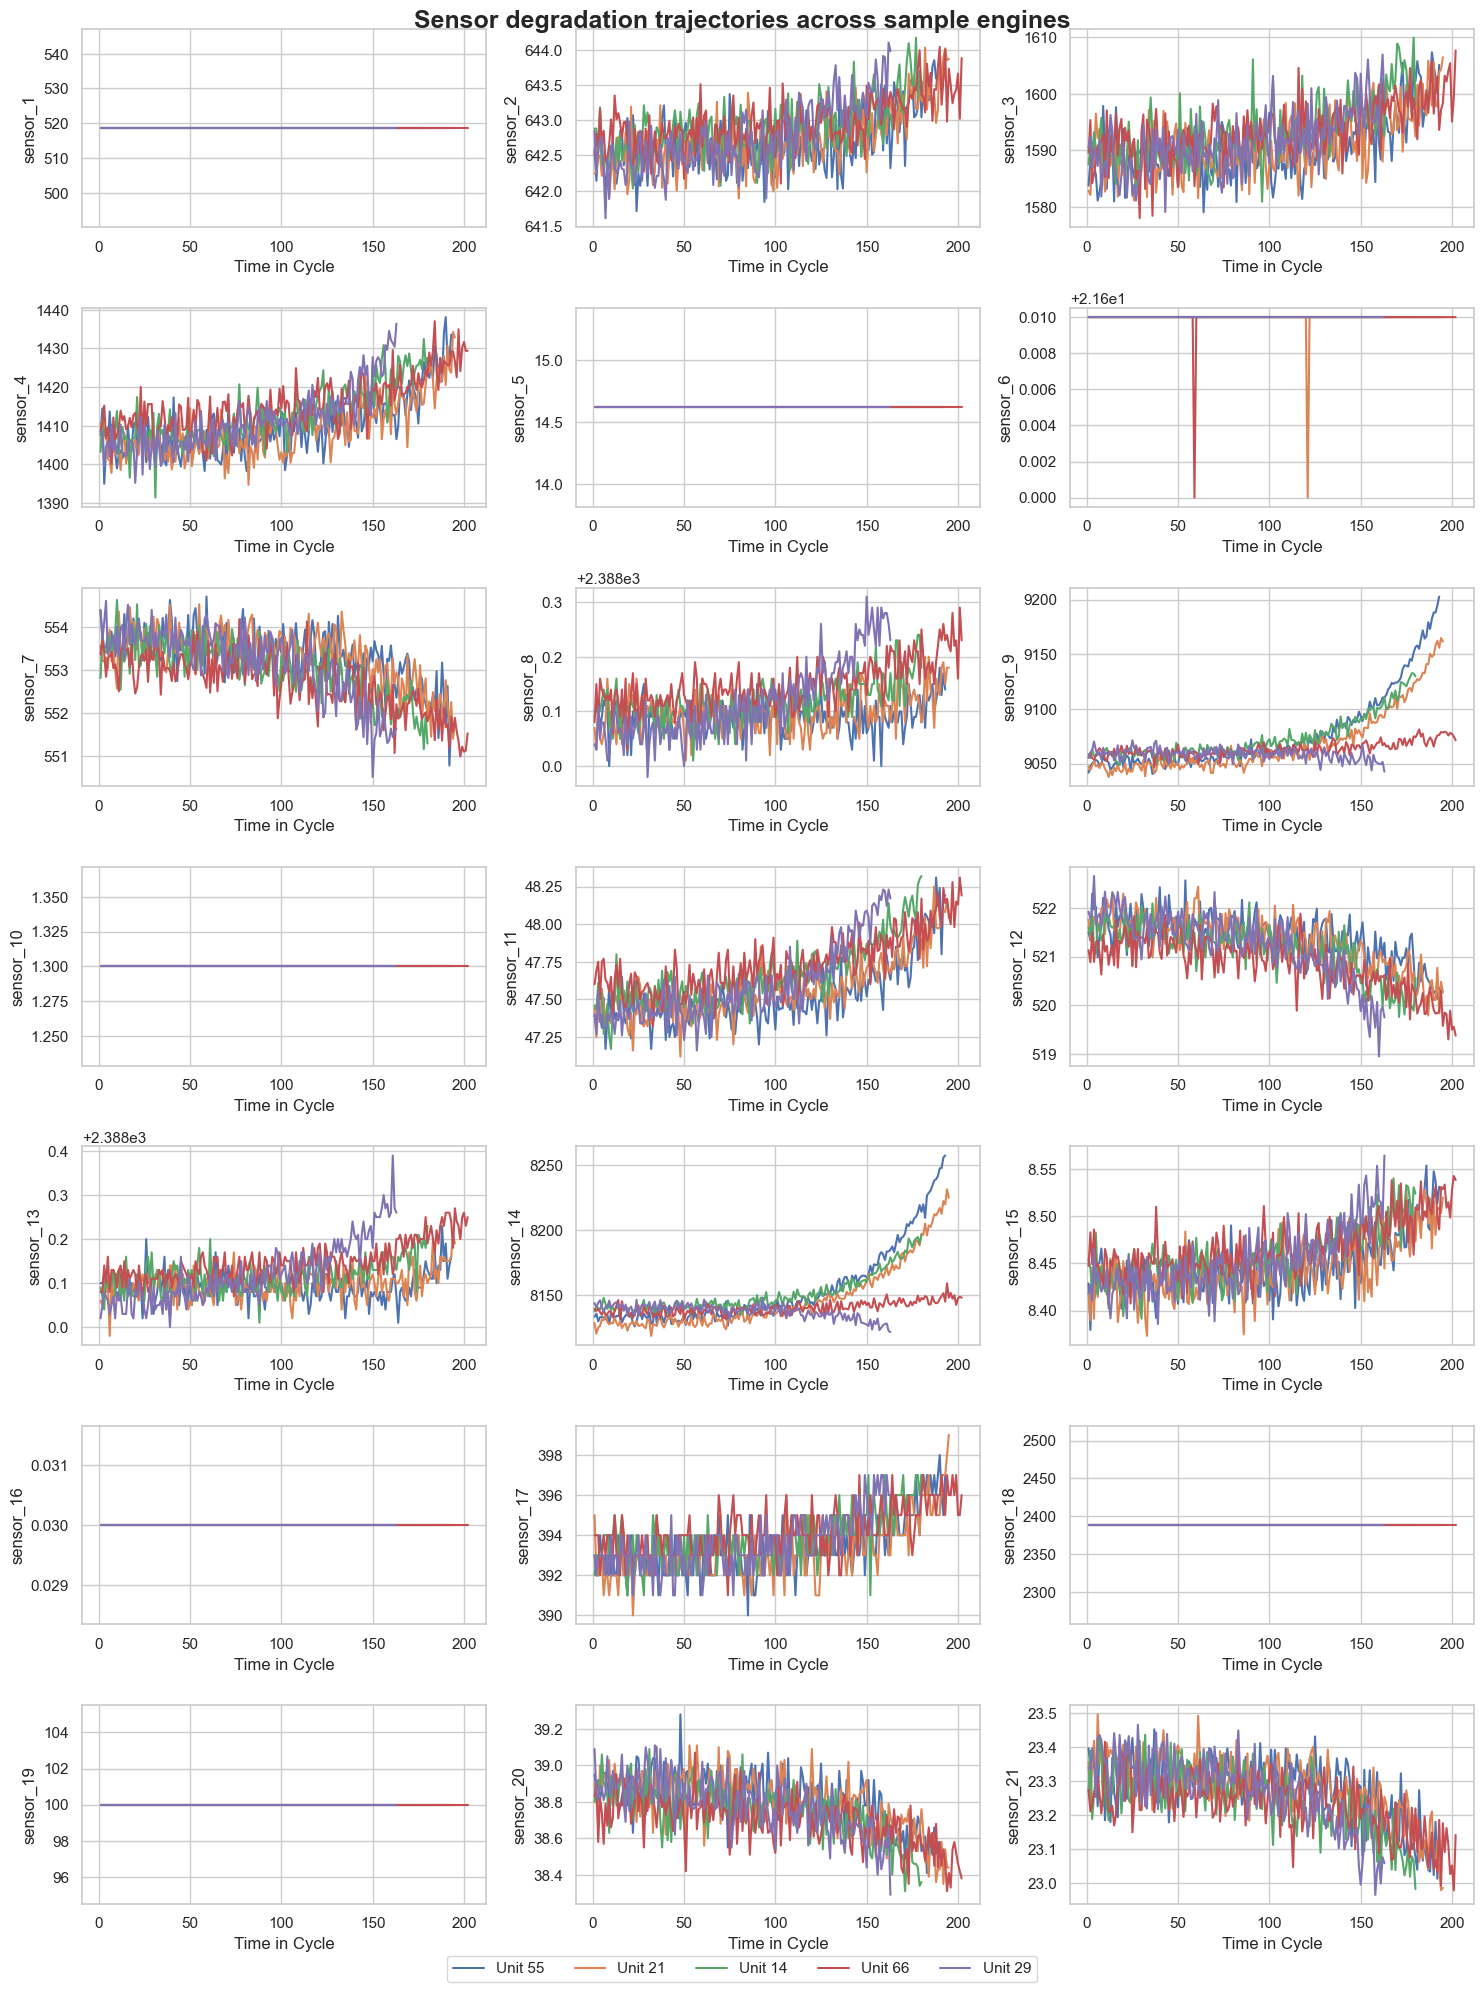

In [ ]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
plot_sensor_trajectories(df, sensor_cols)

In [ ]:
def find_low_variance_sensor(df, sensor_list, threshold):
    stats = {}
    for sensor in sensor_list:
        stats[sensor] = np.std(df[sensor]) / np.mean(abs(df[sensor]))
    low_variance = [s for s in stats if stats[s] < threshold]
    return low_variance, stats

In [ ]:
results = find_low_variance_sensor(df, sensor_cols, 0.0001)
print(f"Sensors with CoV < 0.0001 dropped: {results[0]}")

config_path = Path("../src/config.py")

with open (config_path, 'w+') as f:
    f.write(f"ALL_SENSORS_COLUMNS = {sensor_cols!r}\n")
    f.write(f"DROPPED_SENSORS = {results[0]!r}\n")

Sensors with CoV < 0.0001 dropped: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_16', 'sensor_18', 'sensor_19']


In [ ]:
def correlation_with_rul(df, sensor_list):
    correlation = {}
    for sensor in sensor_list:
        correlation[sensor] = np.corrcoef(df[sensor], df['RUL'])[1, 0]
    return sorted(correlation.items(),key=lambda x: abs(x[1]),reverse=True)


def sensor_pairwise_correlation(df, sensor_list):
    corr_matrix = df[sensor_list].corr()
    return corr_matrix

In [ ]:
sensor_cols_cov = [s for s in sensor_cols if s not in results[0]]
correlation_with_rul(df, sensor_cols_cov)


[('sensor_11', np.float64(-0.6962281014554195)),
 ('sensor_4', np.float64(-0.6789482333860453)),
 ('sensor_12', np.float64(0.6719831036132901)),
 ('sensor_7', np.float64(0.6572226620548839)),
 ('sensor_15', np.float64(-0.6426670441973745)),
 ('sensor_21', np.float64(0.635662042180292)),
 ('sensor_20', np.float64(0.6294284994377345)),
 ('sensor_2', np.float64(-0.6064839743783383)),
 ('sensor_17', np.float64(-0.606153553782966)),
 ('sensor_3', np.float64(-0.5845203909175877)),
 ('sensor_9', np.float64(-0.39010157491807096)),
 ('sensor_14', np.float64(-0.30676887025758437))]

In [ ]:
sensor_pairwise_correlation(df, sensor_cols_cov)

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
sensor_2,1.000000,0.602610,0.714949,-0.702136,0.273764,0.740020,-0.724578,0.179752,0.675975,0.629886,-0.661841,-0.668050
sensor_3,0.602610,1.000000,0.678413,-0.664595,0.322964,0.695900,-0.680307,0.237137,0.639921,0.600017,-0.625941,-0.633901
sensor_4,0.714949,0.678413,1.000000,-0.793130,0.297429,0.830136,-0.815591,0.190748,0.758459,0.703499,-0.748067,-0.745193
sensor_7,-0.702136,-0.664595,-0.793130,1.000000,-0.217835,-0.822805,0.812713,-0.110053,-0.747051,-0.692893,0.736163,0.737447
sensor_9,0.273764,0.322964,0.297429,-0.217835,1.000000,0.274591,-0.210238,0.963157,0.293753,0.337110,-0.285280,-0.292795
sensor_11,0.740020,0.695900,0.830136,-0.822805,0.274591,1.000000,-0.846884,0.163408,0.780913,0.722296,-0.771510,-0.772554
sensor_12,-0.724578,-0.680307,-0.815591,0.812713,-0.210238,-0.846884,1.000000,-0.098141,-0.766052,-0.703485,0.751943,0.756263
sensor_14,0.179752,0.237137,0.190748,-0.110053,0.963157,0.163408,-0.098141,1.000000,0.193761,0.246621,-0.187364,-0.192415
sensor_15,0.675975,0.639921,0.758459,-0.747051,0.293753,0.780913,-0.766052,0.193761,1.000000,0.669205,-0.707671,-0.704043
sensor_17,0.629886,0.600017,0.703499,-0.692893,0.337110,0.722296,-0.703485,0.246621,0.669205,1.000000,-0.651021,-0.658710


In [ ]:
def compare_train_test_distribution(train_df, test_df, sensor_list):
    results = []
    n_rows = int(np.ceil(len(sensor_list) / 2))

    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows))
    fig.suptitle("Train vs Test distribution comparison",fontsize=18,fontweight="bold")
    axes = axes.flatten()

    for i, sensor in enumerate(sensor_list):
        axes[i].hist(train_df[sensor], bins=40, density=True, alpha=0.5, label="Train", color="steelblue")
        axes[i].hist(test_df[sensor], bins=40, density=True, alpha=0.5, label="Test", color="orange")

        sns.kdeplot(train_df[sensor], ax=axes[i], color="steelblue", linewidth=2, label="Train KDE")
        sns.kdeplot(test_df[sensor], ax=axes[i], color="orange", linewidth=2, label="Test KDE")

        stat, p_value = stats.ks_2samp(train_df[sensor], test_df[sensor])
        results.append({
            "sensor": sensor,
            "ks_stats": stat,
            "p_value": p_value,
        })
        axes[i].set_xlabel(sensor)
        axes[i].set_ylabel("Density")
        axes[i].legend()
        axes[i].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    ranked_results = pd.DataFrame(results)

    return ranked_results

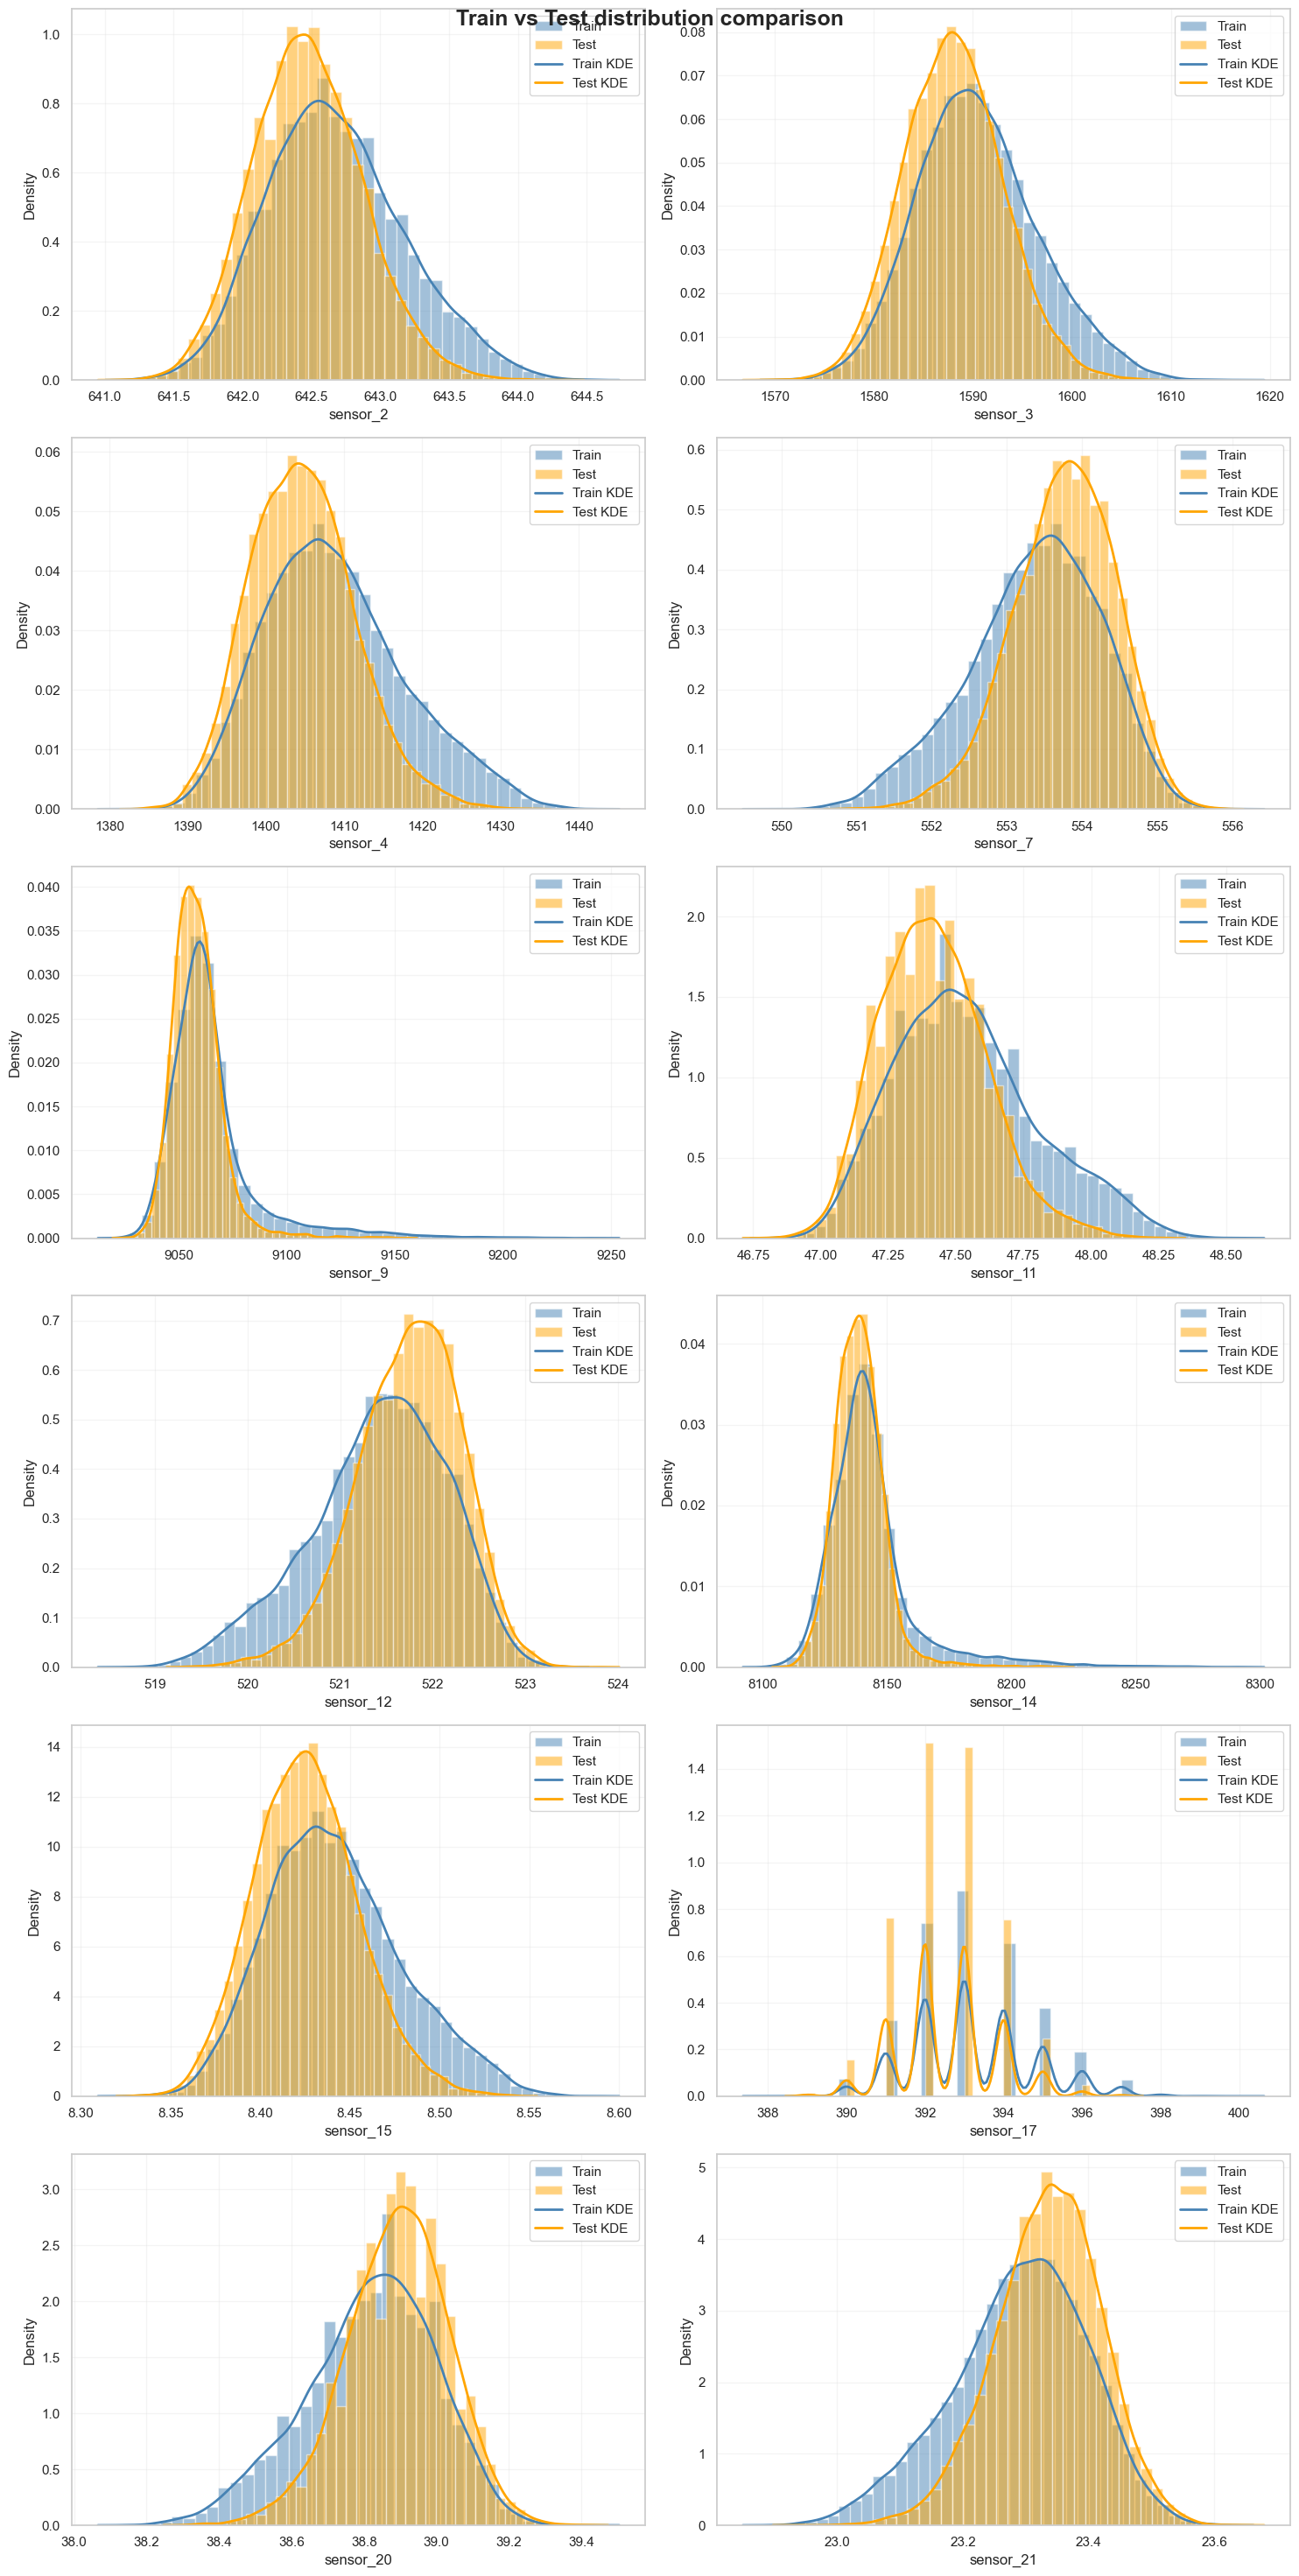

,sensor,ks_stats,p_value
0,sensor_2,0.179419,4.250077e-226
1,sensor_3,0.167776,1.404433e-197
2,sensor_4,0.210650,2.333248e-312
3,sensor_7,0.194772,1.025015e-266
4,sensor_9,0.135336,1.971989e-128
5,sensor_11,0.210781,9.425539e-313
6,sensor_12,0.199367,1.521352e-279
7,sensor_14,0.115590,1.054273e-93
8,sensor_15,0.194231,3.160424e-265
9,sensor_17,0.181091,2.362172e-230


In [ ]:
train_path = Path("../data/train_FD001.txt")
test_path = Path("../data/test_FD001.txt")
train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=columns)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=columns)


compare_train_test_distribution(train_df, test_df, sensor_cols_cov)

In [ ]:
def check_operating_conditions(df, op_setting_cols):
    for col in op_setting_cols:
        print(df[col].describe())

    unique_cols = df[op_setting_cols].round(2).drop_duplicates()
    print(unique_cols)

In [ ]:
op_settings_cols = [f"op_settings_{i}" for i in range(1, 4)]

check_operating_conditions(df, op_settings_cols)

count    20631.000000
mean        -0.000009
std          0.002187
min         -0.008700
25%         -0.001500
50%          0.000000
75%          0.001500
max          0.008700
Name: op_settings_1, dtype: float64
count    20631.000000
mean         0.000002
std          0.000293
min         -0.000600
25%         -0.000200
50%          0.000000
75%          0.000300
max          0.000600
Name: op_settings_2, dtype: float64
count    20631.0
mean       100.0
std          0.0
min        100.0
25%        100.0
50%        100.0
75%        100.0
max        100.0
Name: op_settings_3, dtype: float64
     op_settings_1  op_settings_2  op_settings_3
0            -0.00           -0.0          100.0
187          -0.01            0.0          100.0
216           0.01            0.0          100.0
